In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

In [116]:
### Read the data "vehicle.csv"
vehicle_data = pd.read_csv("vehicle1.csv")
print(vehicle_data.info())
print(vehicle_data.head(5))
print(vehicle_data.describe().transpose())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
compactness                    846 non-null int64
circularity                    841 non-null float64
distance_circularity           842 non-null float64
radius_ratio                   840 non-null float64
pr.axis_aspect_ratio           844 non-null float64
max.length_aspect_ratio        846 non-null int64
scatter_ratio                  845 non-null float64
elongatedness                  845 non-null float64
pr.axis_rectangularity         843 non-null float64
max.length_rectangularity      846 non-null int64
scaled_variance                843 non-null float64
scaled_variance.1              844 non-null float64
scaled_radius_of_gyration      844 non-null float64
scaled_radius_of_gyration.1    842 non-null float64
skewness_about                 840 non-null float64
skewness_about.1               845 non-null float64
skewness_about.2               845 non-null float64
hollows_ratio    

In [117]:
vehicle_data.isnull().any()

compactness                    False
circularity                     True
distance_circularity            True
radius_ratio                    True
pr.axis_aspect_ratio            True
max.length_aspect_ratio        False
scatter_ratio                   True
elongatedness                   True
pr.axis_rectangularity          True
max.length_rectangularity      False
scaled_variance                 True
scaled_variance.1               True
scaled_radius_of_gyration       True
scaled_radius_of_gyration.1     True
skewness_about                  True
skewness_about.1                True
skewness_about.2                True
hollows_ratio                  False
class                          False
dtype: bool

In [118]:
def find_cols_with_missing_values():
    count = 0
    for col in vehicle_data.columns:
        if (vehicle_data[col].isnull().sum()):
            count += 1
            print ("Column {} has {} missing values".format(col, vehicle_data[col].isnull().sum()))
    if (count == 0):
        print ("There are no missing values")

In [119]:
find_cols_with_missing_values()
# Replace missing values with median
vehicle_data.fillna(vehicle_data.median(), inplace=True)

Column circularity has 5 missing values
Column distance_circularity has 4 missing values
Column radius_ratio has 6 missing values
Column pr.axis_aspect_ratio has 2 missing values
Column scatter_ratio has 1 missing values
Column elongatedness has 1 missing values
Column pr.axis_rectangularity has 3 missing values
Column scaled_variance has 3 missing values
Column scaled_variance.1 has 2 missing values
Column scaled_radius_of_gyration has 2 missing values
Column scaled_radius_of_gyration.1 has 4 missing values
Column skewness_about has 6 missing values
Column skewness_about.1 has 1 missing values
Column skewness_about.2 has 1 missing values


In [120]:
num_of_outliers = 0
def find_and_treat_outliers (col):
    global num_of_outliers
    q1 = np.percentile(vehicle_data[col],25)
    q3 = np.percentile(vehicle_data[col],75)
    iqr = q3 - q1
    median = np.percentile(vehicle_data[col],50)
    out_min = np.subtract(q1,(1.5*iqr))
    out_max = np.add(q3,(1.5*iqr))
    outlier_present = 0;
    for rows in range(1,len(vehicle_data)):
        if (vehicle_data[col].loc[rows] < out_min):
            vehicle_data[col].loc[rows] = q1
            num_of_outliers += 1
        elif (vehicle_data[col].loc[rows] > out_max):
            vehicle_data[col].loc[rows] = q3
            num_of_outliers += 1

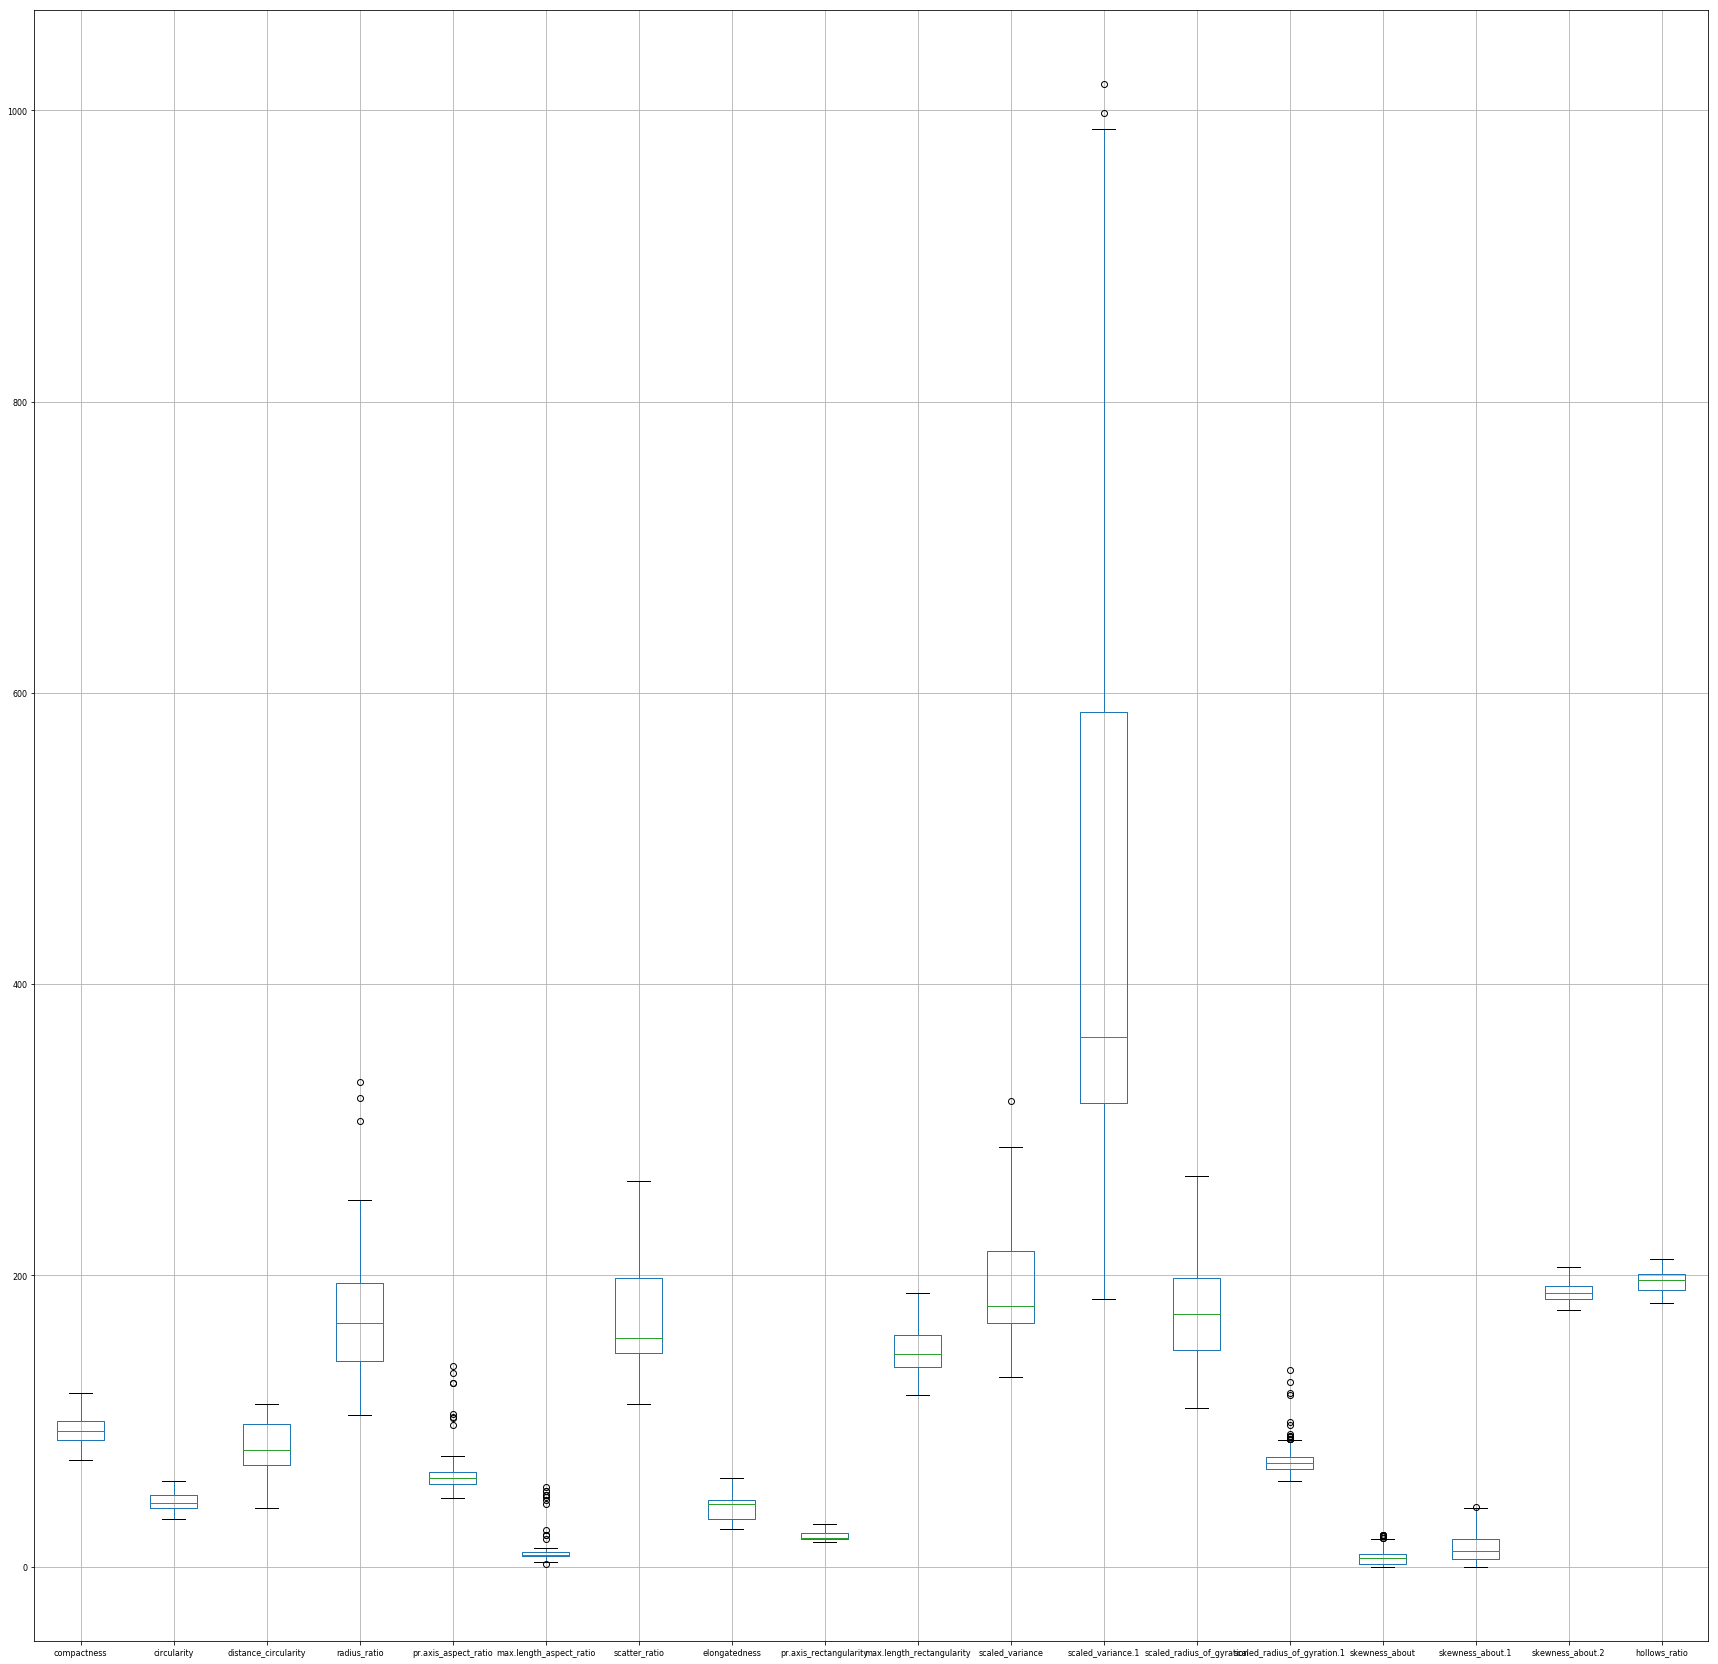

In [121]:
vehicle_data.boxplot(figsize=(30,30), fontsize=8)
plt.show()

In [122]:
for cols in vehicle_data.columns:
    if (cols != 'class'):
        find_and_treat_outliers(cols)

In [123]:
print (num_of_outliers)

55


# Understanding the attributes - Find relationship between different attributes (Independent variables) and choose carefully which all attributes have to be a part of the analysis and why (5 points)

In [124]:
# Finding correlated independent variables and removing those which has minimum correlation with the target variable
def perfect_correlated_columns (threshold):
    cols_to_retain = ['class']
    corr_mat = vehicle_data.corr()
    corr_mat = np.abs(corr_mat)
    for col in corr_mat.columns:
        perfect_corr = corr_mat[col][corr_mat[col] > threshold].index.tolist()
        max_corr = 0
        for attr in perfect_corr:
            if (np.abs(vehicle_data[attr].corr(vehicle_data['class'])) > max_corr):
                max_corr = np.abs(vehicle_data[attr].corr(vehicle_data['class']))
                max_col = attr
        if (max_col not in cols_to_retain):
            cols_to_retain.append(max_col)
    return cols_to_retain

In [125]:
#Encoding class variable to numeric
labelencoder = LabelEncoder()
vehicle_data['class'] = labelencoder.fit_transform(vehicle_data['class'])

In [126]:
# Drop columns which have absolute correlation less than 0.1

for cols in vehicle_data.columns:
    if (np.abs(vehicle_data[cols].corr(vehicle_data['class'])) < 0.1):
        vehicle_data.drop(cols, axis=1,inplace=True)

# Use PCA from scikit learn and elbow plot to find out reduced number of dimension (which covers more than 95% of the variance) - 10 points

In [127]:
def pca():
    X = vehicle_data.drop('class',axis=1)
    y = vehicle_data['class']
    std_scale = StandardScaler()
    X_std = std_scale.fit_transform(X)

    cov_matrix = np.cov(X_std.T)
    eig_vals,eig_vecs = np.linalg.eig(cov_matrix)
    idx = np.argsort(eig_vals)
    eig_vals = eig_vals[idx]
    eig_vecs = eig_vecs[idx]
    eig_vals =np.flip(eig_vals,axis=0)
    eig_vecs = np.flip(eig_vecs,axis=0)


    variance_explained = (eig_vals/np.sum(eig_vals))*100
    var_cols = range(1,cov_matrix.shape[1]+1)
    plt.plot(var_cols,variance_explained)
    plt.show()
    
    total_var = 0
    n_comp = 0
    
    # Choosing the number number of components with 95% variance
    for var in variance_explained:
        total_var += var
        if (total_var <= 95):
            n_comp += 1
        else:
            break;
    print ("Number of components {}".format(n_comp))
    X_reduced = PCA(n_components=n_comp).fit_transform(X_std)
    return X_reduced

# Use Support vector machines and use grid search (try C values - 0.01, 0.05, 0.5, 1 and kernel = linear, rbf) and find out the best hyper parameters and do cross validation to find the accuracy. (10 points)

In [128]:
X = vehicle_data.drop(labels= "class" , axis = 1)
y = vehicle_data[["class"]]

In [129]:
# Function for GrindSearch

#X_train,x_test,Y_train,y_test

def grid_search(X_reduced):
    X_train,x_test,y_train,y_test = train_test_split (X_reduced,y,test_size=0.30,random_state=1)


    parameters = {'kernel':('linear', 'rbf'), 'C':[0.01, 0.05, 0.5, 1]}
    svc = svm.SVC()
    clf = GridSearchCV(svc, parameters)
    clf.fit(X_train,y_train)
    print(clf.best_params_)
    return clf.best_params_

In [130]:
def supportvm(X_reduced):
    best_params = grid_search(X_reduced)
    model = svm.SVC(C=best_params['C'], kernel=best_params['kernel'])
    model.fit(X_train, y_train)
    # check the accuracy on the training set
    print("==============Model score on the training set=====================")
    print(model.score(X_train, y_train))
    y_pred = model.predict(x_test)
    print ("================Classification report==============================")
    print(classification_report(y_pred, y_test))
    print("=================Confusion matrix==================================")
    print(confusion_matrix(y_pred, y_test))
    print("==================Accuracy score===================================")
    print(accuracy_score(y_pred,y_test))
    return best_params

In [131]:
def kcross_val (splits,c,kernel_type):
    acc_scores = []
    kf = KFold(n_splits=splits)
    for train, test in kf.split(X,y):
        X_train, X_test, y_train, y_test = np.array(X_reduced)[train], np.array(X_reduced)[test], np.array(y)[train],np.array(y)[test]
        model= svm.SVC(C=c,kernel=kernel_type)
       	model.fit(X_train,y_train)       
        y_pred = model.predict(X_test)
        acc_scores.append(accuracy_score(y_pred,y_test))
    return acc_scores

In [132]:
X_train,x_test,y_train,y_test = train_test_split (X_reduced,y,test_size=0.30,random_state=1)

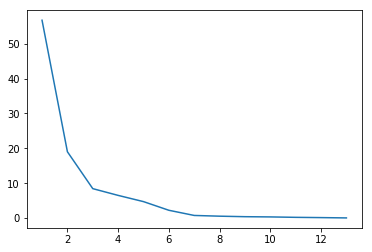

Number of components 4
(846, 4)
{'C': 1, 'kernel': 'rbf'}
==============Model score on the training set=====================
0.8243243243243243
================Classification report==============================
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        60
           1       0.92      0.79      0.85       155
           2       0.52      0.82      0.63        39

   micro avg       0.81      0.81      0.81       254
   macro avg       0.78      0.83      0.79       254
weighted avg       0.85      0.81      0.82       254

=================Confusion matrix==================================
[[ 53   5   2]
 [  5 122  28]
 [  1   6  32]]
==================Accuracy score===================================
0.8149606299212598
================= K-Fold accuracy scores =====================
0.8062184873949579


In [133]:
X_reduced = pca()

print(X_reduced.shape)
best_params = supportvm(X_reduced)
acc_scores = kcross_val(10,best_params['C'],best_params['kernel'])
print ("================= K-Fold accuracy scores =====================")
print (np.mean(acc_scores))

In [134]:
# Removing independent variables which have an absolute correlation > 0.8
cols_to_retain = perfect_correlated_columns(0.8)
for cols in vehicle_data.columns:
    if (cols not in cols_to_retain):
        vehicle_data.drop(cols, axis = 1,inplace=True)
print(cols_to_retain)

['class', 'elongatedness', 'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scaled_radius_of_gyration', 'scaled_radius_of_gyration.1', 'skewness_about']


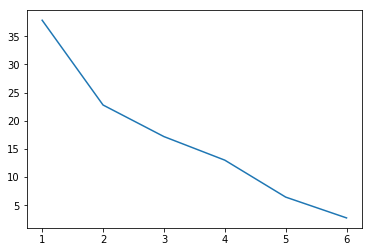

Number of components 4
(846, 4)
{'C': 0.5, 'kernel': 'rbf'}
==============Model score on the training set=====================
0.8175675675675675
================Classification report==============================
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        59
           1       0.94      0.74      0.83       170
           2       0.35      0.88      0.51        25

   micro avg       0.78      0.78      0.78       254
   macro avg       0.73      0.83      0.74       254
weighted avg       0.87      0.78      0.81       254

=================Confusion matrix==================================
[[ 52   5   2]
 [  7 125  38]
 [  0   3  22]]
==================Accuracy score===================================
0.7834645669291339
================= K-Fold accuracy scores =====================
0.7991596638655462


In [135]:
X_reduced = pca()

print(X_reduced.shape)
best_params = supportvm(X_reduced)
acc_scores = kcross_val(10,best_params['C'],best_params['kernel'])
print ("================= K-Fold accuracy scores =====================")
print (np.mean(acc_scores))